In [7]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import dagshub
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, classification_report)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

from imblearn.over_sampling import SMOTENC, SMOTE
from imblearn.under_sampling import TomekLinks

from dotenv import load_dotenv
load_dotenv('../.env', override=True)

import os
DAGSHUB_USERNAME  = os.environ['DAGSHUB_USERNAME']
DAGSHUB_REPO_NAME = os.environ['DAGSHUB_REPO_NAME']
DAGSHUB_TOKEN     = os.environ['DAGSHUB_TOKEN']
MLFLOW_EXPERIMENT = os.getenv('MLFLOW_EXPERIMENT', 'wine-quality')
REGISTERED_MODEL  = os.getenv('MLFLOW_MODEL_NAME',  'wine-quality')

print("✅ Imports OK")


✅ Imports OK


## Carregando Dataset

In [8]:
df = pd.read_csv("../data/wine_quality.csv")
# df = pd.read_csv("../data/wine_quality.csv")
print('Classes :', sorted(df['quality'].unique()))
print(df['quality'].value_counts().sort_index().to_string())   


Classes : [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5


## 1. EDA

In [9]:

# ── Visão geral do dataset ───────────────────────────────────
print(f"Shape: {df.shape}")
print(f"\nTipos:\n{df.dtypes}")
print(f"\nValores nulos:\n{df.isnull().sum()}")
print(f"\nEstatísticas descritivas:")
df.describe().T.style.background_gradient(cmap="Blues", subset=["mean","std","min","max"])


Shape: (6497, 13)

Tipos:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
type                     object
dtype: object

Valores nulos:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

Estatísticas descritivas:


,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.000000,7.215307,1.296434,3.800000,6.400000,7.000000,7.700000,15.900000
volatile acidity,6497.000000,0.339666,0.164636,0.080000,0.230000,0.290000,0.400000,1.580000
citric acid,6497.000000,0.318633,0.145318,0.000000,0.250000,0.310000,0.390000,1.660000
residual sugar,6497.000000,5.443235,4.757804,0.600000,1.800000,3.000000,8.100000,65.800000
chlorides,6497.000000,0.056034,0.035034,0.009000,0.038000,0.047000,0.065000,0.611000
free sulfur dioxide,6497.000000,30.525319,17.749400,1.000000,17.000000,29.000000,41.000000,289.000000
total sulfur dioxide,6497.000000,115.744574,56.521855,6.000000,77.000000,118.000000,156.000000,440.000000
density,6497.000000,0.994697,0.002999,0.987110,0.992340,0.994890,0.996990,1.038980
pH,6497.000000,3.218501,0.160787,2.720000,3.110000,3.210000,3.320000,4.010000
sulphates,6497.000000,0.531268,0.148806,0.220000,0.430000,0.510000,0.600000,2.000000


### 1.1 Distribuição da variável alvo (`quality`)

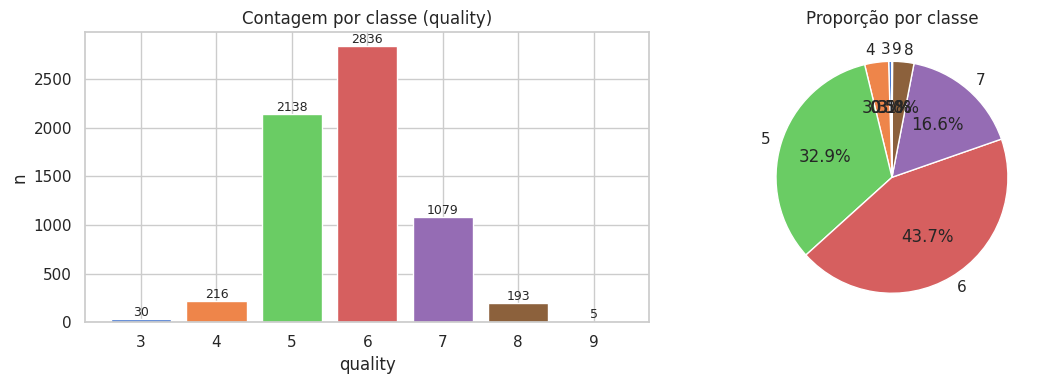

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5


In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Contagem absoluta
vc = df["quality"].value_counts().sort_index()
axes[0].bar(vc.index.astype(str), vc.values, color=sns.color_palette("muted", len(vc)))
axes[0].set_title("Contagem por classe (quality)")
axes[0].set_xlabel("quality")
axes[0].set_ylabel("n")
for bar, v in zip(axes[0].patches, vc.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 str(v), ha="center", va="bottom", fontsize=9)

# Proporção
axes[1].pie(vc.values, labels=vc.index.astype(str), autopct="%1.1f%%",
            colors=sns.color_palette("muted", len(vc)), startangle=90)
axes[1].set_title("Proporção por classe")

plt.tight_layout()
plt.show()
print(vc.to_string())


### 1.2 Histogramas das features

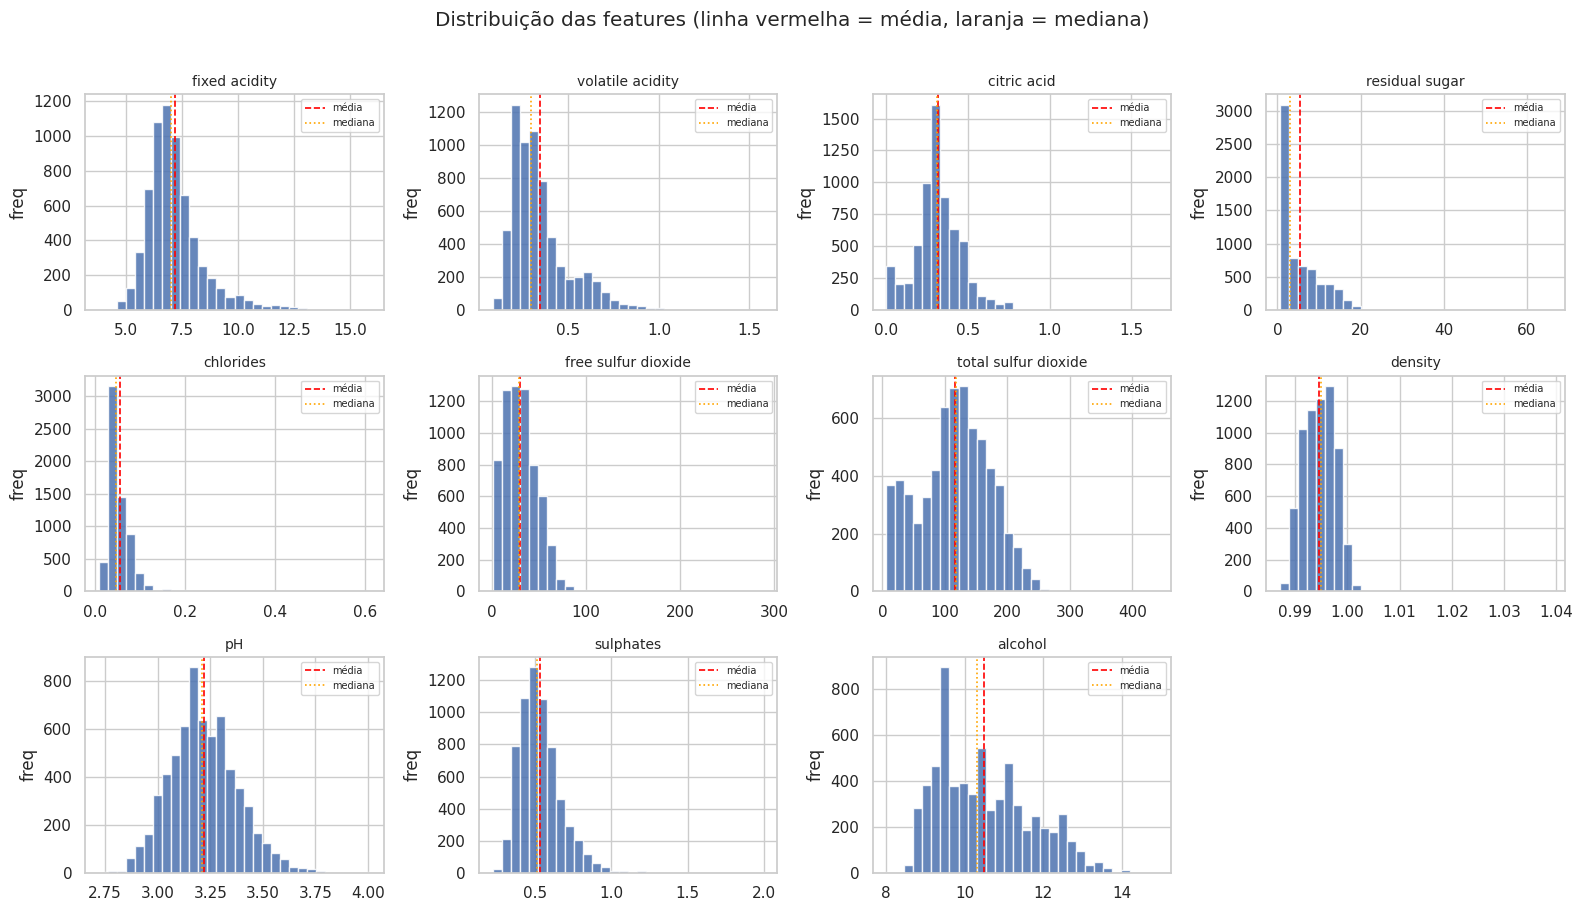

In [11]:
feat_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != "quality"]
n = len(feat_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(feat_cols):
    axes[i].hist(df[col].dropna(), bins=30, color="#4C72B0", edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("freq")
    # linha de média e mediana
    axes[i].axvline(df[col].mean(),   color="red",    linestyle="--", linewidth=1.2, label="média")
    axes[i].axvline(df[col].median(), color="orange", linestyle=":",  linewidth=1.2, label="mediana")
    axes[i].legend(fontsize=7)

# esconder eixos extras
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribuição das features (linha vermelha = média, laranja = mediana)", y=1.01)
plt.tight_layout()
plt.show()


### 1.3 Boxplots por classe de qualidade

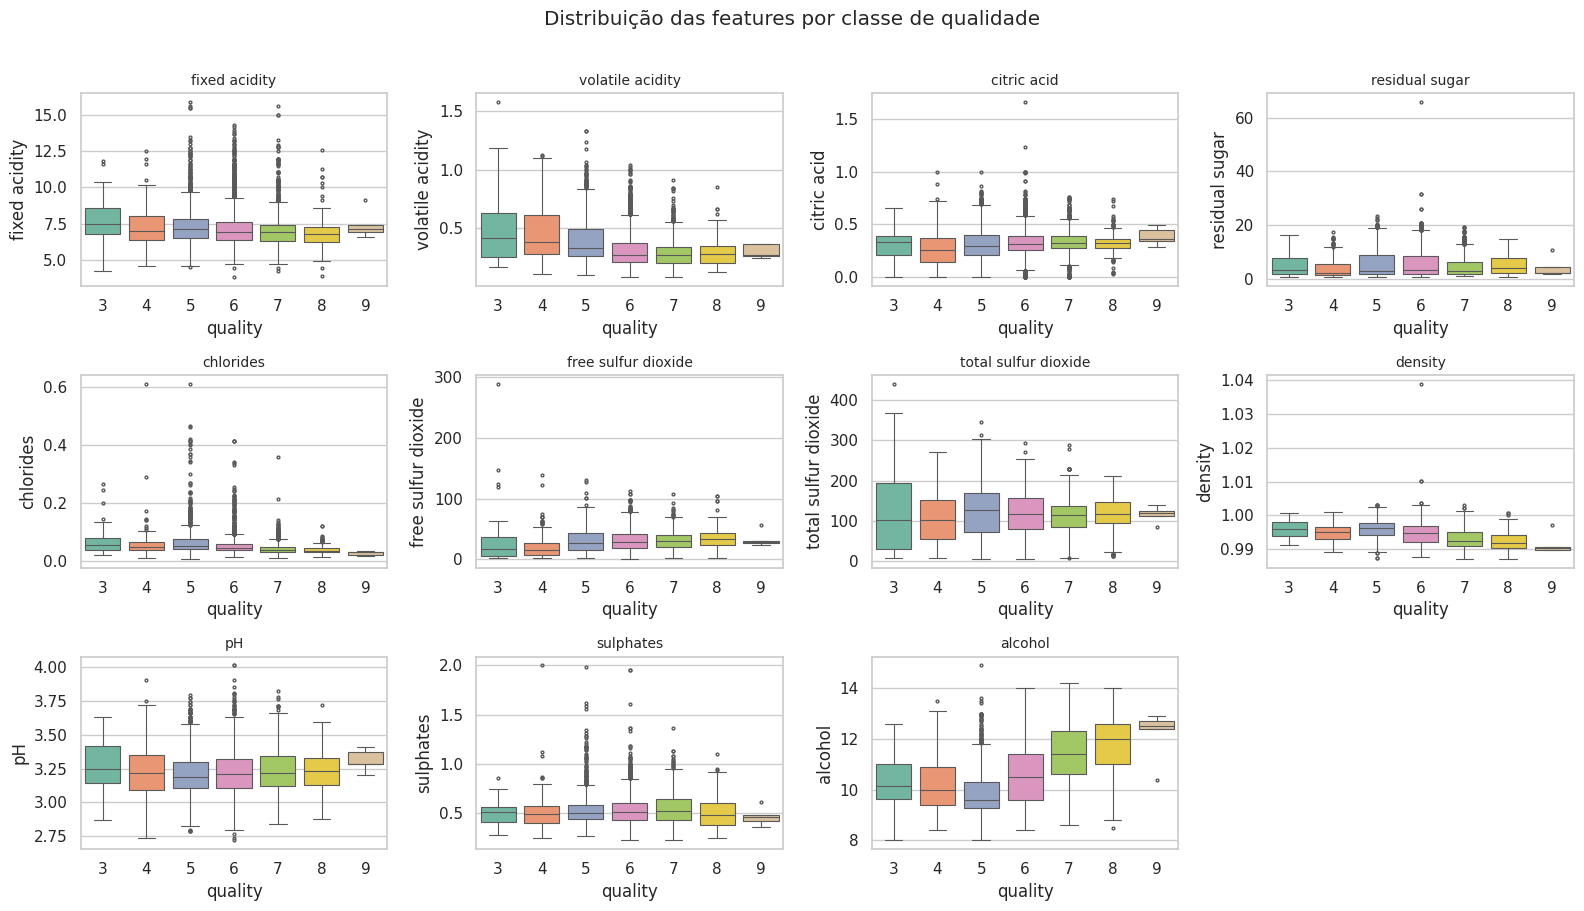

In [12]:
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(feat_cols):
    sns.boxplot(data=df, x="quality", y=col, ax=axes[i],
                palette="Set2", linewidth=0.8, fliersize=2)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("quality")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribuição das features por classe de qualidade", y=1.01)
plt.tight_layout()
plt.show()


### 1.4 Matriz de correlação

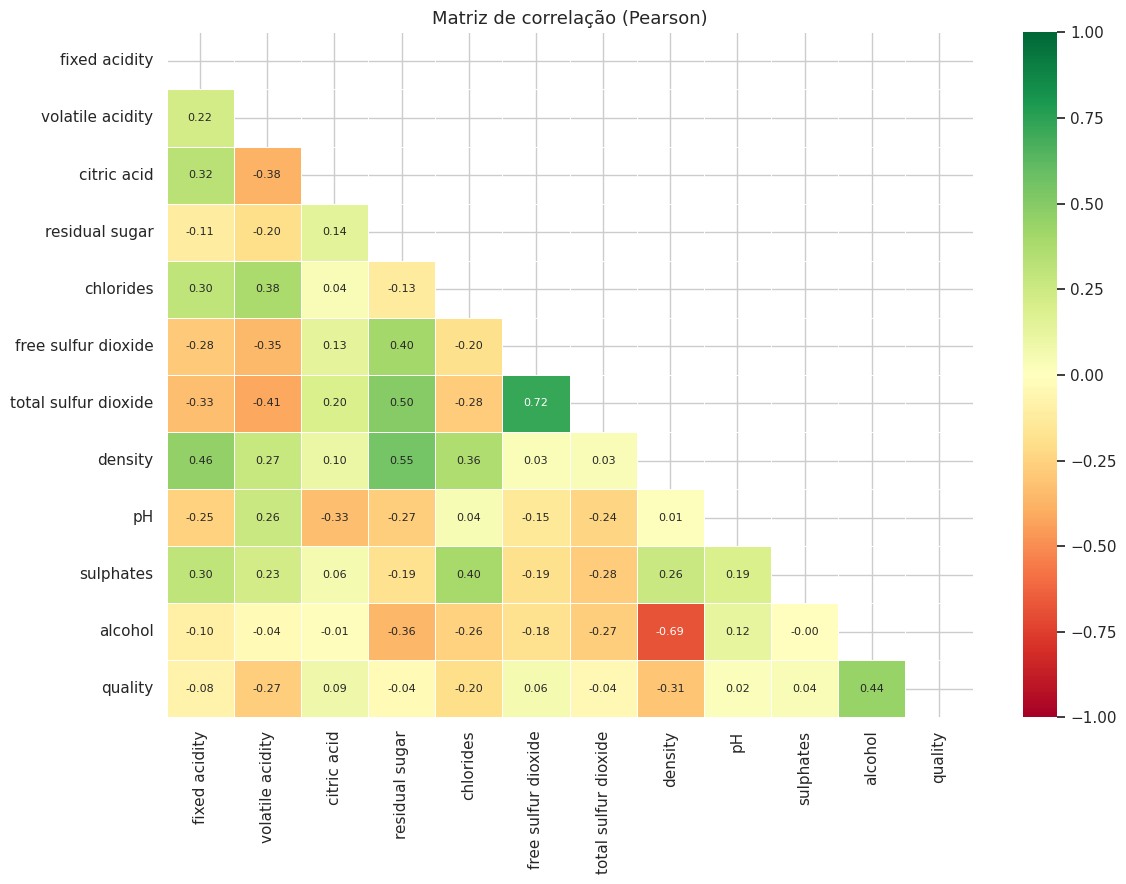


Correlação com 'quality' (ordenada):
alcohol                 0.444319
density                -0.305858
volatile acidity       -0.265699
chlorides              -0.200666
citric acid             0.085532
fixed acidity          -0.076743
free sulfur dioxide     0.055463
total sulfur dioxide   -0.041385
sulphates               0.038485
residual sugar         -0.036980
pH                      0.019506


In [13]:
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))   # mostrar só metade inferior
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, linewidths=0.5, ax=ax,
    annot_kws={"size": 8},
    vmin=-1, vmax=1,
)
ax.set_title("Matriz de correlação (Pearson)", fontsize=13)
plt.tight_layout()
plt.show()

# Destacar features mais correlacionadas com quality
print("\nCorrelação com 'quality' (ordenada):")
print(corr["quality"].drop("quality").sort_values(key=abs, ascending=False).to_string())


### 1.5 Detecção de outliers (IQR)

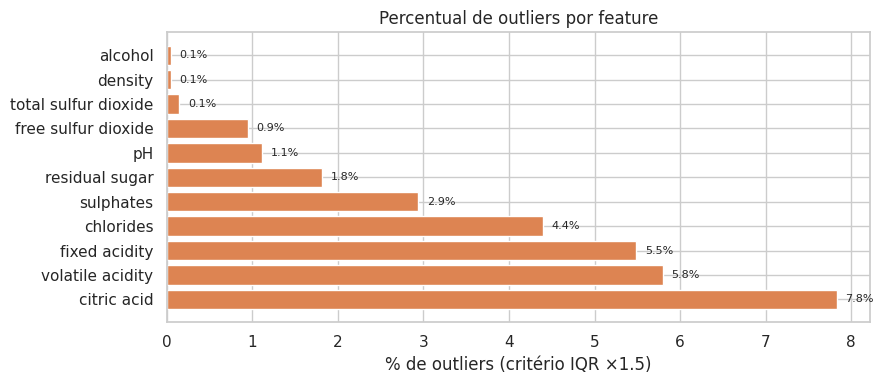

                      n_outliers   pct
citric acid                  509  7.83
volatile acidity             377  5.80
fixed acidity                357  5.49
chlorides                    286  4.40
sulphates                    191  2.94
residual sugar               118  1.82
pH                            73  1.12
free sulfur dioxide           62  0.95
total sulfur dioxide          10  0.15
density                        3  0.05
alcohol                        3  0.05


In [14]:
Q1  = df[feat_cols].quantile(0.25)
Q3  = df[feat_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[feat_cols] < (Q1 - 1.5 * IQR)) | (df[feat_cols] > (Q3 + 1.5 * IQR))).sum()

outlier_df = (
    pd.DataFrame({"n_outliers": outliers, "pct": (outliers / len(df) * 100).round(2)})
    .sort_values("pct", ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(outlier_df.index, outlier_df["pct"], color="#DD8452")
ax.set_xlabel("% de outliers (critério IQR ×1.5)")
ax.set_title("Percentual de outliers por feature")
for bar, pct in zip(ax.patches, outlier_df["pct"]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.show()

print(outlier_df.to_string())


## 2. Fusão de Classes
| Label | Classe original | Descrição |
|-------|-----------------|-----------|
| **0** | 3, 4, 5 | Ruim |
| **1** | 6 | Médio |
| **2** | 7, 8, 9 | Bom |


In [15]:
df_merged = df.copy()
df_merged["quality"] = df["quality"].apply(lambda x: "0" if x <= 5 else ("1" if x == 6 else "2"))
df_merged['quality'].replace("0",0, inplace=True)
df_merged['quality'].replace("1",1, inplace=True)
df_merged['quality'].replace("2",2, inplace=True)

# separar X e y
X = df_merged.drop(columns=['quality'])
y_orig = df_merged['quality']
print('Classes após fusão:', sorted(df_merged['quality'].unique()))
print(df_merged['quality'].value_counts().sort_index().to_string())



Classes após fusão: [np.int64(0), np.int64(1), np.int64(2)]
quality
0    2384
1    2836
2    1277


## 3. Split Treino / Validação / Teste  (60 / 20 / 20)

In [16]:
# 1ª divisão: 80% temp + 20% teste
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_orig, test_size=0.20, random_state=42, stratify=y_orig
)
# 2ª divisão: 75% treino + 25% validação  →  60% / 20% do total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

total = len(X)
print(f"Treino:    {len(X_train):>5} amostras  ({len(X_train)/total*100:.1f}%)")
print(f"Validação: {len(X_val):>5} amostras  ({len(X_val)/total*100:.1f}%)")
print(f"Teste:     {len(X_test):>5} amostras  ({len(X_test)/total*100:.1f}%)")
print("\nDistribuição no treino:")
print(y_train.value_counts().sort_index())


Treino:     3897 amostras  (60.0%)
Validação:  1300 amostras  (20.0%)
Teste:      1300 amostras  (20.0%)

Distribuição no treino:
quality
0    1430
1    1701
2     766
Name: count, dtype: int64


### Models

In [17]:
# ── Identificar colunas ──────────────────────────────────────
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
cat_idx  = [X.columns.get_loc(c) for c in cat_cols]

print(f"Numéricas  ({len(num_cols)}): {num_cols}")
print(f"Categóricas({len(cat_cols)}): {cat_cols}")

# ── Fábrica de pré-processador ───────────────────────────────
def make_preprocessor():
    steps = [("num", StandardScaler(), num_cols)]
    if cat_cols:
        steps.append(("cat",
                       OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                       cat_cols))
    return ColumnTransformer(steps)

# ── Fábrica de modelos (instâncias frescas) ───────────────────
def get_models():
    return {
        "logistic_regression": LogisticRegression(max_iter=1000, random_state=42),
        "random_forest":       RandomForestClassifier(n_estimators=100, random_state=42),
        "knn":                 KNeighborsClassifier(),
        "svm":                 SVC(random_state=42),
        "xgboost":             XGBClassifier(eval_metric="mlogloss", random_state=42),
        "mlp":                 MLPClassifier(hidden_layer_sizes=(200, 100),
                                             max_iter=2000, random_state=42),
    }

# ── Cálculo de métricas ───────────────────────────────────────
def compute_metrics(y_true, y_pred, prefix=""):
    return {
        f"{prefix}accuracy":  round(accuracy_score(y_true, y_pred), 4),
        f"{prefix}precision": round(precision_score(y_true, y_pred,
                                                    average="weighted",
                                                    zero_division=0), 4),
        f"{prefix}recall":    round(recall_score(y_true, y_pred,
                                                 average="weighted",
                                                 zero_division=0), 4),
        f"{prefix}f1":        round(f1_score(y_true, y_pred,
                                             average="weighted",
                                             zero_division=0), 4),
    }

print("✅ Utilitários definidos")


Numéricas  (11): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Categóricas(1): ['type']
✅ Utilitários definidos


## 5. Configuração DagHub / MLflow

In [18]:
dagshub.init(repo_owner=DAGSHUB_USERNAME, repo_name=DAGSHUB_REPO_NAME, mlflow=True)
mlflow.set_experiment("wine_quality_classification")

print("✅ MLflow tracking URI:", mlflow.get_tracking_uri())


Accessing as frpbotero

Initialized MLflow to track repo "frpbotero/wine-quality"

Repository frpbotero/wine-quality initialized!

2026/05/06 20:41:35 INFO mlflow.tracking.fluent: Experiment with name 'wine_quality_classification' does not exist. Creating a new experiment.


✅ MLflow tracking URI: https://dagshub.com/frpbotero/wine-quality.mlflow


---
## Estratégia 1 — SMOTE (Over-sampling)
Aplica **SMOTENC** (suporte a features categóricas) no conjunto de treino para  
balancear as classes.  
Cada modelo é embrulhado num `Pipeline` com pré-processador próprio.


### 6. Aplicar SMOTE ao conjunto de treino

In [19]:
if cat_idx:
    sampler = SMOTENC(categorical_features=cat_idx, random_state=42)
    print("Usando SMOTENC (há features categóricas)")
else:
    sampler = SMOTE(random_state=42)
    print("Usando SMOTE (apenas features numéricas)")

X_train_smote, y_train_smote = sampler.fit_resample(X_train, y_train)

# Manter como DataFrame para compatibilidade com o Pipeline
X_train_smote = pd.DataFrame(X_train_smote, columns=X_train.columns)
y_train_smote = np.array(y_train_smote, dtype=int)

print("\nDistribuição após SMOTE:")
print(pd.Series(y_train_smote).value_counts().sort_index())
print(f"\nTotal de amostras: {len(X_train_smote)}")


Usando SMOTENC (há features categóricas)

Distribuição após SMOTE:
0    1701
1    1701
2    1701
Name: count, dtype: int64

Total de amostras: 5103


### 7. Treinar, validar, testar e registrar — SMOTE

In [20]:
STRATEGY = "SMOTE"
results_smote = {}

for model_name, model in get_models().items():
    print(f"\n{'='*60}")
    print(f"  Estratégia: {STRATEGY}  |  Modelo: {model_name}")
    print(f"{'='*60}")

    # ── Pipeline: pré-processador + classificador ─────────────
    pipeline = Pipeline([
        ("preprocessor", make_preprocessor()),
        ("classifier",   model),
    ])

    # ── Treino ────────────────────────────────────────────────
    pipeline.fit(X_train_smote, y_train_smote)

    # ── Validação ─────────────────────────────────────────────
    y_val_pred  = pipeline.predict(X_val)
    val_metrics = compute_metrics(y_val, y_val_pred, prefix="val_")

    # ── Teste ─────────────────────────────────────────────────
    y_test_pred  = pipeline.predict(X_test)
    test_metrics = compute_metrics(y_test, y_test_pred, prefix="test_")

    all_metrics = {**val_metrics, **test_metrics}
    results_smote[model_name] = all_metrics

    # ── Imprimir resultados ───────────────────────────────────
    print(f"  Validação → Acc:{val_metrics['val_accuracy']:.4f}  "
          f"P:{val_metrics['val_precision']:.4f}  "
          f"R:{val_metrics['val_recall']:.4f}  "
          f"F1:{val_metrics['val_f1']:.4f}")
    print(f"  Teste     → Acc:{test_metrics['test_accuracy']:.4f}  "
          f"P:{test_metrics['test_precision']:.4f}  "
          f"R:{test_metrics['test_recall']:.4f}  "
          f"F1:{test_metrics['test_f1']:.4f}")
    print("\n" + classification_report(y_test, y_test_pred,
                                        target_names=["Ruim(0)", "Médio(1)", "Bom(2)"]))

    # ── Log no DagHub / MLflow ────────────────────────────────
    with mlflow.start_run(run_name=f"{STRATEGY}_{model_name}"):
        mlflow.log_param("strategy",      STRATEGY)
        mlflow.log_param("model",         model_name)
        mlflow.log_param("train_samples", int(len(X_train_smote)))
        mlflow.log_param("val_samples",   int(len(X_val)))
        mlflow.log_param("test_samples",  int(len(X_test)))
        mlflow.log_metrics(all_metrics)
        mlflow.sklearn.log_model(
            pipeline,
            artifact_path="model",
            registered_model_name=f"wine_{STRATEGY}_{model_name}",
        )
    print(f"  ✅ Registrado → wine_{STRATEGY}_{model_name}")

print("\n🎉 SMOTE — todos os modelos registrados no DagHub!")



  Estratégia: SMOTE  |  Modelo: logistic_regression
  Validação → Acc:0.5515  P:0.5692  R:0.5515  F1:0.5428
  Teste     → Acc:0.5438  P:0.5595  R:0.5438  F1:0.5353

              precision    recall  f1-score   support

     Ruim(0)       0.63      0.68      0.65       477
    Médio(1)       0.56      0.36      0.44       567
      Bom(2)       0.43      0.70      0.53       256

    accuracy                           0.54      1300
   macro avg       0.54      0.58      0.54      1300
weighted avg       0.56      0.54      0.54      1300



2026/05/06 20:41:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 20:41:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'wine_SMOTE_logistic_regression' already exists. Creating a new version of this model...
2026/05/06 20:41:56 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: wine_SMOTE_logistic_regression, version 4
Created version '4' of model 'wine_SMOTE_logistic_regression'.


🏃 View run SMOTE_logistic_regression at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1/runs/7db03cf4f64d4b17ad333f5aa8bcc1fc
🧪 View experiment at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1
  ✅ Registrado → wine_SMOTE_logistic_regression

  Estratégia: SMOTE  |  Modelo: random_forest
  Validação → Acc:0.6792  P:0.6816  R:0.6792  F1:0.6780
  Teste     → Acc:0.6908  P:0.6941  R:0.6908  F1:0.6896

              precision    recall  f1-score   support

     Ruim(0)       0.75      0.78      0.76       477
    Médio(1)       0.69      0.60      0.64       567
      Bom(2)       0.60      0.73      0.66       256

    accuracy                           0.69      1300
   macro avg       0.68      0.70      0.69      1300
weighted avg       0.69      0.69      0.69      1300



2026/05/06 20:42:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 20:42:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'wine_SMOTE_random_forest' already exists. Creating a new version of this model...
2026/05/06 20:42:31 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: wine_SMOTE_random_forest, version 4
Created version '4' of model 'wine_SMOTE_random_forest'.


🏃 View run SMOTE_random_forest at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1/runs/2a1202a03b3c4dc8a874a97cd5df32c8
🧪 View experiment at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1
  ✅ Registrado → wine_SMOTE_random_forest

  Estratégia: SMOTE  |  Modelo: knn
  Validação → Acc:0.5823  P:0.5912  R:0.5823  F1:0.5787
  Teste     → Acc:0.5838  P:0.5905  R:0.5838  F1:0.5805

              precision    recall  f1-score   support

     Ruim(0)       0.64      0.67      0.65       477
    Médio(1)       0.59      0.46      0.52       567
      Bom(2)       0.50      0.70      0.58       256

    accuracy                           0.58      1300
   macro avg       0.58      0.61      0.58      1300
weighted avg       0.59      0.58      0.58      1300



...

🏃 View run SMOTE_svm at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1/runs/38fa270cb0154d69b5a8ce99772f39ae
🧪 View experiment at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1
  ✅ Registrado → wine_SMOTE_svm

  Estratégia: SMOTE  |  Modelo: xgboost
  Validação → Acc:0.6815  P:0.6817  R:0.6815  F1:0.6803
  Teste     → Acc:0.6685  P:0.6706  R:0.6685  F1:0.6679

              precision    recall  f1-score   support

     Ruim(0)       0.73      0.74      0.74       477
    Médio(1)       0.66      0.60      0.63       567
      Bom(2)       0.58      0.69      0.63       256

    accuracy                           0.67      1300
   macro avg       0.66      0.68      0.66      1300
weighted avg       0.67      0.67      0.67      1300



2026/05/06 20:44:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 20:44:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'wine_SMOTE_xgboost' already exists. Creating a new version of this model...
2026/05/06 20:44:34 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: wine_SMOTE_xgboost, version 4
Created version '4' of model 'wine_SMOTE_xgboost'.


🏃 View run SMOTE_xgboost at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1/runs/12d27cbfb5374ba9b08a114f3cb9d539
🧪 View experiment at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1
  ✅ Registrado → wine_SMOTE_xgboost

  Estratégia: SMOTE  |  Modelo: mlp
  Validação → Acc:0.6562  P:0.6578  R:0.6562  F1:0.6567
  Teste     → Acc:0.6585  P:0.6614  R:0.6585  F1:0.6590

              precision    recall  f1-score   support

     Ruim(0)       0.71      0.65      0.68       477
    Médio(1)       0.62      0.67      0.64       567
      Bom(2)       0.66      0.65      0.66       256

    accuracy                           0.66      1300
   macro avg       0.66      0.66      0.66      1300
weighted avg       0.66      0.66      0.66      1300



2026/05/06 20:46:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 20:47:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'wine_SMOTE_mlp' already exists. Creating a new version of this model...
2026/05/06 20:47:11 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: wine_SMOTE_mlp, version 4
Created version '4' of model 'wine_SMOTE_mlp'.


🏃 View run SMOTE_mlp at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1/runs/f0eb3213df9c4804b4bf2ef5b9986e7f
🧪 View experiment at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1
  ✅ Registrado → wine_SMOTE_mlp

🎉 SMOTE — todos os modelos registrados no DagHub!


---
## Estratégia 2 — Tomek Links (Under-sampling)
**TomekLinks** requer features numéricas, portanto o pré-processamento  
é aplicado primeiro e compartilhado entre todos os modelos.


### 8. Pré-processar e aplicar Tomek Links

In [21]:
# ── Pré-processamento ────────────────────────────────────────
preprocessor_tomek = make_preprocessor()
X_train_trans = preprocessor_tomek.fit_transform(X_train)
X_val_trans   = preprocessor_tomek.transform(X_val)
X_test_trans  = preprocessor_tomek.transform(X_test)

y_train_int = y_train.values.astype(int)
y_val_int   = y_val.values.astype(int)
y_test_int  = y_test.values.astype(int)

# ── Tomek Links ───────────────────────────────────────────────
tomek = TomekLinks()
X_train_tomek, y_train_tomek = tomek.fit_resample(X_train_trans, y_train_int)

print("Distribuição após Tomek Links:")
print(pd.Series(y_train_tomek).value_counts().sort_index())
print(f"\nAmostras removidas: {len(X_train_trans) - len(X_train_tomek)}")


Distribuição após Tomek Links:
0    1231
1    1447
2     766
Name: count, dtype: int64

Amostras removidas: 453


### 9. Treinar, validar, testar e registrar — Tomek Links

In [22]:
STRATEGY = "Tomek"
results_tomek = {}

for model_name, model in get_models().items():
    print(f"\n{'='*60}")
    print(f"  Estratégia: {STRATEGY}  |  Modelo: {model_name}")
    print(f"{'='*60}")

    # ── Treino direto nos dados já transformados ───────────────
    model.fit(X_train_tomek, y_train_tomek)

    # ── Validação ─────────────────────────────────────────────
    y_val_pred  = model.predict(X_val_trans)
    val_metrics = compute_metrics(y_val_int, y_val_pred, prefix="val_")

    # ── Teste ─────────────────────────────────────────────────
    y_test_pred  = model.predict(X_test_trans)
    test_metrics = compute_metrics(y_test_int, y_test_pred, prefix="test_")

    all_metrics = {**val_metrics, **test_metrics}
    results_tomek[model_name] = all_metrics

    # ── Imprimir resultados ───────────────────────────────────
    print(f"  Validação → Acc:{val_metrics['val_accuracy']:.4f}  "
          f"P:{val_metrics['val_precision']:.4f}  "
          f"R:{val_metrics['val_recall']:.4f}  "
          f"F1:{val_metrics['val_f1']:.4f}")
    print(f"  Teste     → Acc:{test_metrics['test_accuracy']:.4f}  "
          f"P:{test_metrics['test_precision']:.4f}  "
          f"R:{test_metrics['test_recall']:.4f}  "
          f"F1:{test_metrics['test_f1']:.4f}")
    print("\n" + classification_report(y_test_int, y_test_pred,
                                        target_names=["Ruim(0)", "Médio(1)", "Bom(2)"]))

    # ── Log no DagHub / MLflow ────────────────────────────────
    with mlflow.start_run(run_name=f"{STRATEGY}_{model_name}"):
        mlflow.log_param("strategy",      STRATEGY)
        mlflow.log_param("model",         model_name)
        mlflow.log_param("train_samples", int(len(X_train_tomek)))
        mlflow.log_param("val_samples",   int(len(X_val_trans)))
        mlflow.log_param("test_samples",  int(len(X_test_trans)))
        mlflow.log_metrics(all_metrics)

        # Modelo treinado
        mlflow.sklearn.log_model(
            model,
            artifact_path="model",
            registered_model_name=f"wine_{STRATEGY}_{model_name}",
        )
        # Pré-processador compartilhado (necessário para inferência futura)
        mlflow.sklearn.log_model(
            preprocessor_tomek,
            artifact_path="preprocessor",
        )
    print(f"  ✅ Registrado → wine_{STRATEGY}_{model_name}")

print("\n🎉 Tomek — todos os modelos registrados no DagHub!")



  Estratégia: Tomek  |  Modelo: logistic_regression
  Validação → Acc:0.5869  P:0.5861  R:0.5869  F1:0.5845
  Teste     → Acc:0.5815  P:0.5848  R:0.5815  F1:0.5802

              precision    recall  f1-score   support

     Ruim(0)       0.65      0.62      0.63       477
    Médio(1)       0.54      0.61      0.57       567
      Bom(2)       0.57      0.44      0.50       256

    accuracy                           0.58      1300
   macro avg       0.59      0.56      0.57      1300
weighted avg       0.58      0.58      0.58      1300



2026/05/06 20:47:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 20:47:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'wine_Tomek_logistic_regression' already exists. Creating a new version of this model...
2026/05/06 20:47:45 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: wine_Tomek_logistic_regression, version 4
Created version '4' of model 'wine_Tomek_logistic_regression'.
2026/05/06 20:47:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 20:48:01 WARNING m

🏃 View run Tomek_logistic_regression at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1/runs/1c09a3a744cb44489a5691be7f7e5d08
🧪 View experiment at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1
  ✅ Registrado → wine_Tomek_logistic_regression

  Estratégia: Tomek  |  Modelo: random_forest
  Validação → Acc:0.6823  P:0.6829  R:0.6823  F1:0.6825
  Teste     → Acc:0.6969  P:0.6978  R:0.6969  F1:0.6973

              precision    recall  f1-score   support

     Ruim(0)       0.75      0.73      0.74       477
    Médio(1)       0.66      0.68      0.67       567
      Bom(2)       0.67      0.67      0.67       256

    accuracy                           0.70      1300
   macro avg       0.70      0.69      0.69      1300
weighted avg       0.70      0.70      0.70      1300



2026/05/06 20:48:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 20:48:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'wine_Tomek_random_forest' already exists. Creating a new version of this model...
2026/05/06 20:48:51 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: wine_Tomek_random_forest, version 4
Created version '4' of model 'wine_Tomek_random_forest'.
2026/05/06 20:48:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 20:49:00 WARNING mlflow.sklearn: Sav

🏃 View run Tomek_random_forest at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1/runs/5986fe2dd8a04f20a76679ad4664fe56
🧪 View experiment at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1
  ✅ Registrado → wine_Tomek_random_forest

  Estratégia: Tomek  |  Modelo: knn
  Validação → Acc:0.6131  P:0.6119  R:0.6131  F1:0.6115
  Teste     → Acc:0.5992  P:0.5995  R:0.5992  F1:0.5994

              precision    recall  f1-score   support

     Ruim(0)       0.64      0.64      0.64       477
    Médio(1)       0.58      0.58      0.58       567
      Bom(2)       0.56      0.57      0.57       256

    accuracy                           0.60      1300
   macro avg       0.59      0.60      0.60      1300
weighted avg       0.60      0.60      0.60      1300



...

🏃 View run Tomek_svm at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1/runs/f65d96419a5c46bd8ca318a578a9a24d
🧪 View experiment at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1
  ✅ Registrado → wine_Tomek_svm

  Estratégia: Tomek  |  Modelo: xgboost
  Validação → Acc:0.6731  P:0.6725  R:0.6731  F1:0.6728
  Teste     → Acc:0.6808  P:0.6822  R:0.6808  F1:0.6813

              precision    recall  f1-score   support

     Ruim(0)       0.74      0.71      0.72       477
    Médio(1)       0.65      0.66      0.66       567
      Bom(2)       0.64      0.67      0.66       256

    accuracy                           0.68      1300
   macro avg       0.68      0.68      0.68      1300
weighted avg       0.68      0.68      0.68      1300



2026/05/06 20:51:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 20:51:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'wine_Tomek_xgboost' already exists. Creating a new version of this model...
2026/05/06 20:51:26 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: wine_Tomek_xgboost, version 3
Created version '3' of model 'wine_Tomek_xgboost'.
2026/05/06 20:51:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 20:51:41 WARNING mlflow.sklearn: Saving scikit-learn m

🏃 View run Tomek_xgboost at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1/runs/1131e7b4d49b443fb5a12a9849daa5cb
🧪 View experiment at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1
  ✅ Registrado → wine_Tomek_xgboost

  Estratégia: Tomek  |  Modelo: mlp
  Validação → Acc:0.6531  P:0.6575  R:0.6531  F1:0.6519
  Teste     → Acc:0.6423  P:0.6474  R:0.6423  F1:0.6422

              precision    recall  f1-score   support

     Ruim(0)       0.71      0.69      0.70       477
    Médio(1)       0.64      0.57      0.60       567
      Bom(2)       0.56      0.71      0.62       256

    accuracy                           0.64      1300
   macro avg       0.63      0.66      0.64      1300
weighted avg       0.65      0.64      0.64      1300



2026/05/06 20:52:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 20:52:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'wine_Tomek_mlp' already exists. Creating a new version of this model...
2026/05/06 20:52:40 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: wine_Tomek_mlp, version 3
Created version '3' of model 'wine_Tomek_mlp'.
2026/05/06 20:52:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 20:52:56 WARNING mlflow.sklearn: Saving scikit-learn models in the

🏃 View run Tomek_mlp at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1/runs/02b681ad3d164fd29d5aa37817635be4
🧪 View experiment at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1
  ✅ Registrado → wine_Tomek_mlp

🎉 Tomek — todos os modelos registrados no DagHub!


---
## 10. Resumo Final

---
## Estratégia 3 — GridSearch (Otimização de Hiperparâmetros)
Usa **GridSearchCV** para encontrar os melhores hiperparâmetros de cada modelo  
com validação cruzada (5 folds).


In [23]:
from sklearn.model_selection import GridSearchCV
import time

print("✅ GridSearchCV importado")

✅ GridSearchCV importado


### 11. Definir grade de hiperparâmetros para cada modelo

In [24]:
# ── Parâmetros para GridSearch ──────────────────────────────
param_grids = {
    "logistic_regression": {
        "classifier__C": [0.001, 0.01, 0.1, 1, 10],
        "classifier__penalty": ["l2"],
        "classifier__solver": ["lbfgs", "liblinear"],
    },
    "random_forest": {
        "classifier__n_estimators": [50, 100, 200],
        "classifier__max_depth": [10, 20, None],
        "classifier__min_samples_split": [2, 5, 10],
    },
    "knn": {
        "classifier__n_neighbors": [3, 5, 7, 9, 11],
        "classifier__weights": ["uniform", "distance"],
        "classifier__metric": ["euclidean", "manhattan"],
    },
    "svm": {
        "classifier__C": [0.1, 1, 10],
        "classifier__kernel": ["linear", "rbf"],
        "classifier__gamma": ["scale", "auto"],
    },
    "xgboost": {
        "classifier__n_estimators": [50, 100, 200],
        "classifier__max_depth": [3, 5, 7],
        "classifier__learning_rate": [0.01, 0.1, 0.3],
    },
    "mlp": {
        "classifier__hidden_layer_sizes": [(100,), (200, 100), (300, 150, 50)],
        "classifier__alpha": [0.0001, 0.001, 0.01],
        "classifier__learning_rate": ["constant", "adaptive"],
    },
}

print("✅ Grades de hiperparâmetros definidas")
for model_name, params in param_grids.items():
    n_combinations = 1
    for p_list in params.values():
        n_combinations *= len(p_list)
    print(f"  {model_name:20} → {n_combinations:4} combinações")


✅ Grades de hiperparâmetros definidas
  logistic_regression  →   10 combinações
  random_forest        →   27 combinações
  knn                  →   20 combinações
  svm                  →   12 combinações
  xgboost              →   27 combinações
  mlp                  →   18 combinações


### 12. GridSearchCV com SMOTE (5-fold cross-validation)

In [25]:
STRATEGY = "GridSearch_SMOTE"
results_gridsearch = {}
best_models_grid = {}

for model_name, model in get_models().items():
    print(f"\n{'='*70}")
    print(f"  Estratégia: {STRATEGY}  |  Modelo: {model_name}")
    print(f"{'='*70}")
    
    start_time = time.time()
    
    # ── Pipeline: pré-processador + classificador ─────────────
    pipeline = Pipeline([
        ("preprocessor", make_preprocessor()),
        ("classifier",   model),
    ])

    # ── GridSearchCV com 5-fold CV ────────────────────────────
    grid_search = GridSearchCV(
        pipeline,
        param_grid=param_grids[model_name],
        cv=5,
        scoring="f1_weighted",
        n_jobs=-1,  # usar todos os cores
        verbose=0,
    )
    
    print(f"  Testando {len(param_grids[model_name])} combinações de parâmetros...")
    grid_search.fit(X_train_smote, y_train_smote)
    
    elapsed = time.time() - start_time
    print(f"  ⏱ Tempo: {elapsed:.1f}s")
    
    # ── Melhor modelo ─────────────────────────────────────────
    best_pipeline = grid_search.best_estimator_
    best_models_grid[model_name] = best_pipeline
    
    print(f"\n  🎯 Melhores parâmetros:")
    for param, value in grid_search.best_params_.items():
        print(f"     {param:30} = {value}")
    print(f"  📊 CV F1 Score (médio): {grid_search.best_score_:.4f}")

    # ── Validação ─────────────────────────────────────────────
    y_val_pred  = best_pipeline.predict(X_val)
    val_metrics = compute_metrics(y_val, y_val_pred, prefix="val_")

    # ── Teste ─────────────────────────────────────────────────
    y_test_pred  = best_pipeline.predict(X_test)
    test_metrics = compute_metrics(y_test, y_test_pred, prefix="test_")

    all_metrics = {**val_metrics, **test_metrics}
    results_gridsearch[model_name] = all_metrics

    # ── Imprimir resultados ───────────────────────────────────
    print(f"\n  Validação → Acc:{val_metrics['val_accuracy']:.4f}  "
          f"P:{val_metrics['val_precision']:.4f}  "
          f"R:{val_metrics['val_recall']:.4f}  "
          f"F1:{val_metrics['val_f1']:.4f}")
    print(f"  Teste     → Acc:{test_metrics['test_accuracy']:.4f}  "
          f"P:{test_metrics['test_precision']:.4f}  "
          f"R:{test_metrics['test_recall']:.4f}  "
          f"F1:{test_metrics['test_f1']:.4f}")
    print("\n" + classification_report(y_test, y_test_pred,
                                        target_names=["Ruim(0)", "Médio(1)", "Bom(2)"]))

    # ── Log no DagHub / MLflow ────────────────────────────────
    with mlflow.start_run(run_name=f"{STRATEGY}_{model_name}"):
        mlflow.log_param("strategy",      STRATEGY)
        mlflow.log_param("model",         model_name)
        mlflow.log_param("cv_folds",      5)
        mlflow.log_param("cv_f1_score",   round(grid_search.best_score_, 4))
        
        # Log dos melhores parâmetros
        for param, value in grid_search.best_params_.items():
            mlflow.log_param(param, str(value))
        
        mlflow.log_param("train_samples", int(len(X_train_smote)))
        mlflow.log_param("val_samples",   int(len(X_val)))
        mlflow.log_param("test_samples",  int(len(X_test)))
        mlflow.log_metrics(all_metrics)
        mlflow.log_metric("training_time", elapsed)
        
        mlflow.sklearn.log_model(
            best_pipeline,
            artifact_path="model",
            registered_model_name=f"wine_{STRATEGY}_{model_name}",
        )
    print(f"\n  ✅ Registrado → wine_{STRATEGY}_{model_name}")

print("\n🎉 GridSearch — todos os modelos otimizados e registrados no DagHub!")



  Estratégia: GridSearch_SMOTE  |  Modelo: logistic_regression
  Testando 3 combinações de parâmetros...
  ⏱ Tempo: 6.0s

  🎯 Melhores parâmetros:
     classifier__C                  = 10
     classifier__penalty            = l2
     classifier__solver             = lbfgs
  📊 CV F1 Score (médio): 0.5873

  Validação → Acc:0.5500  P:0.5678  R:0.5500  F1:0.5411
  Teste     → Acc:0.5438  P:0.5600  R:0.5438  F1:0.5354

              precision    recall  f1-score   support

     Ruim(0)       0.63      0.68      0.65       477
    Médio(1)       0.57      0.36      0.44       567
      Bom(2)       0.43      0.70      0.53       256

    accuracy                           0.54      1300
   macro avg       0.54      0.58      0.54      1300
weighted avg       0.56      0.54      0.54      1300



2026/05/06 20:53:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 20:53:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'wine_GridSearch_SMOTE_logistic_regression'.
2026/05/06 20:53:41 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: wine_GridSearch_SMOTE_logistic_regression, version 1
Created version '1' of model 'wine_GridSearch_SMOTE_logistic_regression'.


🏃 View run GridSearch_SMOTE_logistic_regression at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1/runs/ad62ba21205747a0a5a515b046994a49
🧪 View experiment at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1

  ✅ Registrado → wine_GridSearch_SMOTE_logistic_regression

  Estratégia: GridSearch_SMOTE  |  Modelo: random_forest
  Testando 3 combinações de parâmetros...
  ⏱ Tempo: 15.5s

  🎯 Melhores parâmetros:
     classifier__max_depth          = None
     classifier__min_samples_split  = 2
     classifier__n_estimators       = 200
  📊 CV F1 Score (médio): 0.7430

  Validação → Acc:0.6892  P:0.6918  R:0.6892  F1:0.6885
  Teste     → Acc:0.6838  P:0.6873  R:0.6838  F1:0.6823

              precision    recall  f1-score   support

     Ruim(0)       0.74      0.77      0.76       477
    Médio(1)       0.68      0.59      0.63       567
      Bom(2)       0.59      0.73      0.66       256

    accuracy                           0.68      1300
   macro a

2026/05/06 20:54:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 20:54:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'wine_GridSearch_SMOTE_random_forest'.
2026/05/06 20:54:57 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: wine_GridSearch_SMOTE_random_forest, version 1
Created version '1' of model 'wine_GridSearch_SMOTE_random_forest'.


🏃 View run GridSearch_SMOTE_random_forest at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1/runs/277bea1d585c4c1eb81ea7d655b510d1
🧪 View experiment at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1

  ✅ Registrado → wine_GridSearch_SMOTE_random_forest

  Estratégia: GridSearch_SMOTE  |  Modelo: knn
  Testando 3 combinações de parâmetros...
  ⏱ Tempo: 1.1s

  🎯 Melhores parâmetros:
     classifier__metric             = manhattan
     classifier__n_neighbors        = 3
     classifier__weights            = distance
  📊 CV F1 Score (médio): 0.7200

  Validação → Acc:0.6477  P:0.6539  R:0.6477  F1:0.6458
  Teste     → Acc:0.6500  P:0.6582  R:0.6500  F1:0.6497

              precision    recall  f1-score   support

     Ruim(0)       0.72      0.69      0.71       477
    Médio(1)       0.66      0.57      0.61       567
      Bom(2)       0.55      0.75      0.64       256

    accuracy                           0.65      1300
   macro avg       0.64

...

🏃 View run GridSearch_SMOTE_svm at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1/runs/a91512ad92c04edfa3caa86aafe5102a
🧪 View experiment at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1

  ✅ Registrado → wine_GridSearch_SMOTE_svm

  Estratégia: GridSearch_SMOTE  |  Modelo: xgboost
  Testando 3 combinações de parâmetros...
  ⏱ Tempo: 11.3s

  🎯 Melhores parâmetros:
     classifier__learning_rate      = 0.3
     classifier__max_depth          = 7
     classifier__n_estimators       = 200
  📊 CV F1 Score (médio): 0.7353

  Validação → Acc:0.6915  P:0.6910  R:0.6915  F1:0.6910
  Teste     → Acc:0.6746  P:0.6753  R:0.6746  F1:0.6740

              precision    recall  f1-score   support

     Ruim(0)       0.73      0.75      0.74       477
    Médio(1)       0.66      0.61      0.63       567
      Bom(2)       0.61      0.68      0.64       256

    accuracy                           0.67      1300
   macro avg       0.67      0.68      0.67      

2026/05/06 20:56:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 20:56:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'wine_GridSearch_SMOTE_xgboost'.
2026/05/06 20:56:53 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: wine_GridSearch_SMOTE_xgboost, version 1
Created version '1' of model 'wine_GridSearch_SMOTE_xgboost'.


🏃 View run GridSearch_SMOTE_xgboost at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1/runs/82b0be84fd2946dba0d9d6a9d8ecd13b
🧪 View experiment at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1

  ✅ Registrado → wine_GridSearch_SMOTE_xgboost

  Estratégia: GridSearch_SMOTE  |  Modelo: mlp
  Testando 3 combinações de parâmetros...
  ⏱ Tempo: 246.9s

  🎯 Melhores parâmetros:
     classifier__alpha              = 0.0001
     classifier__hidden_layer_sizes = (300, 150, 50)
     classifier__learning_rate      = constant
  📊 CV F1 Score (médio): 0.7257

  Validação → Acc:0.6431  P:0.6563  R:0.6431  F1:0.6456
  Teste     → Acc:0.6331  P:0.6469  R:0.6331  F1:0.6349

              precision    recall  f1-score   support

     Ruim(0)       0.75      0.60      0.66       477
    Médio(1)       0.61      0.64      0.62       567
      Bom(2)       0.54      0.70      0.61       256

    accuracy                           0.63      1300
   macro avg       0.63

2026/05/06 21:01:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/06 21:01:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'wine_GridSearch_SMOTE_mlp'.
2026/05/06 21:01:31 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: wine_GridSearch_SMOTE_mlp, version 1
Created version '1' of model 'wine_GridSearch_SMOTE_mlp'.


🏃 View run GridSearch_SMOTE_mlp at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1/runs/2c7851d2eb79485894039f1b794fb074
🧪 View experiment at: https://dagshub.com/frpbotero/wine-quality.mlflow/#/experiments/1

  ✅ Registrado → wine_GridSearch_SMOTE_mlp

🎉 GridSearch — todos os modelos otimizados e registrados no DagHub!


---
## 13. Resumo Comparativo — Todas as Estratégias

In [26]:
import pandas as pd

rows = []
for model_name in get_models().keys():
    sm = results_smote.get(model_name, {})
    tk = results_tomek.get(model_name, {})
    gs = results_gridsearch.get(model_name, {})
    rows.append({
        "Modelo":           model_name,
        "SMOTE-F1":         sm.get("test_f1", "-"),
        "SMOTE-Acc":        sm.get("test_accuracy", "-"),
        "Tomek-F1":         tk.get("test_f1", "-"),
        "Tomek-Acc":        tk.get("test_accuracy", "-"),
        "GridSearch-F1":    gs.get("test_f1", "-"),
        "GridSearch-Acc":   gs.get("test_accuracy", "-"),
    })

summary = pd.DataFrame(rows).set_index("Modelo")
print("\n" + "="*100)
print("RESUMO COMPARATIVO — TEST METRICS")
print("="*100)
print(summary.to_string())

print("\n" + "="*100)
print("MELHORES MODELOS POR ESTRATÉGIA")
print("="*100)

try:
    best_smote_f1 = summary["SMOTE-F1"].max()
    best_smote_model = summary["SMOTE-F1"].idxmax()
    print(f"🏆 SMOTE      → {best_smote_model:20} (F1: {best_smote_f1:.4f})")
except:
    print(f"🏆 SMOTE      → sem dados")

try:
    best_tomek_f1 = summary["Tomek-F1"].max()
    best_tomek_model = summary["Tomek-F1"].idxmax()
    print(f"🏆 Tomek      → {best_tomek_model:20} (F1: {best_tomek_f1:.4f})")
except:
    print(f"🏆 Tomek      → sem dados")

try:
    best_grid_f1 = summary["GridSearch-F1"].max()
    best_grid_model = summary["GridSearch-F1"].idxmax()
    print(f"🏆 GridSearch → {best_grid_model:20} (F1: {best_grid_f1:.4f})")
except:
    print(f"🏆 GridSearch → sem dados")

print("\n" + "="*100)



RESUMO COMPARATIVO — TEST METRICS
                     SMOTE-F1  SMOTE-Acc  Tomek-F1  Tomek-Acc  GridSearch-F1  GridSearch-Acc
Modelo                                                                                      
logistic_regression    0.5353     0.5438    0.5802     0.5815         0.5354          0.5438
random_forest          0.6896     0.6908    0.6973     0.6969         0.6823          0.6838
knn                    0.5805     0.5838    0.5994     0.5992         0.6497          0.6500
svm                    0.5923     0.5977    0.6139     0.6154         0.6067          0.6092
xgboost                0.6679     0.6685    0.6813     0.6808         0.6740          0.6746
mlp                    0.6590     0.6585    0.6422     0.6423         0.6349          0.6331

MELHORES MODELOS POR ESTRATÉGIA
🏆 SMOTE      → random_forest        (F1: 0.6896)
🏆 Tomek      → random_forest        (F1: 0.6973)
🏆 GridSearch → random_forest        (F1: 0.6823)



### 14. Visualização Comparativa — Gráfico de Barras

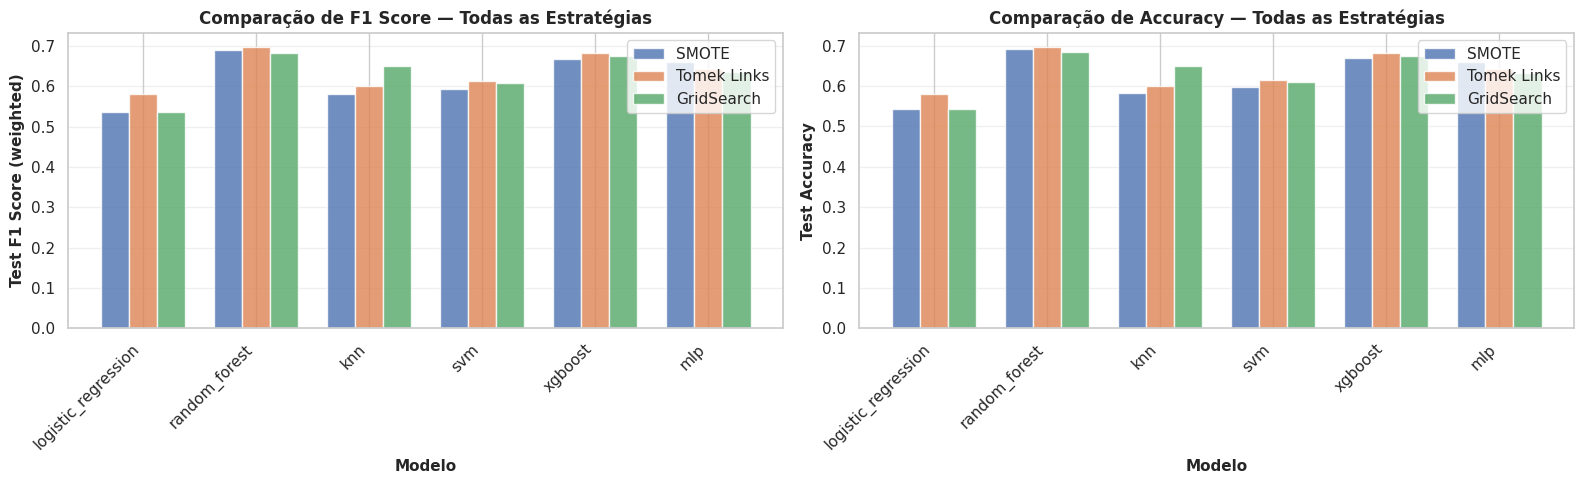

✅ Gráficos de comparação exibidos


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Gráfico F1 Score ─────────────────────────────────────────
x = np.arange(len(summary.index))
width = 0.25

ax = axes[0]
ax.bar(x - width, summary["SMOTE-F1"], width, label="SMOTE", alpha=0.8, color="#4C72B0")
ax.bar(x, summary["Tomek-F1"], width, label="Tomek Links", alpha=0.8, color="#DD8452")
ax.bar(x + width, summary["GridSearch-F1"], width, label="GridSearch", alpha=0.8, color="#55A868")

ax.set_xlabel("Modelo", fontsize=11, fontweight="bold")
ax.set_ylabel("Test F1 Score (weighted)", fontsize=11, fontweight="bold")
ax.set_title("Comparação de F1 Score — Todas as Estratégias", fontsize=12, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(summary.index, rotation=45, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# ── Gráfico Accuracy ────────────────────────────────────────
ax = axes[1]
ax.bar(x - width, summary["SMOTE-Acc"], width, label="SMOTE", alpha=0.8, color="#4C72B0")
ax.bar(x, summary["Tomek-Acc"], width, label="Tomek Links", alpha=0.8, color="#DD8452")
ax.bar(x + width, summary["GridSearch-Acc"], width, label="GridSearch", alpha=0.8, color="#55A868")

ax.set_xlabel("Modelo", fontsize=11, fontweight="bold")
ax.set_ylabel("Test Accuracy", fontsize=11, fontweight="bold")
ax.set_title("Comparação de Accuracy — Todas as Estratégias", fontsize=12, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(summary.index, rotation=45, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Gráficos de comparação exibidos")


### 15. Detalhes dos Melhores Hiperparâmetros (GridSearch)

In [28]:
print("\n" + "="*100)
print("MELHORES HIPERPARÂMETROS POR MODELO (GridSearch)")
print("="*100)

for model_name in get_models().keys():
    if model_name in best_models_grid:
        print(f"\n🔧 {model_name.upper()}")
        print("-" * 100)
        
        best_model = best_models_grid[model_name]
        classifier = best_model.named_steps["classifier"]
        
        # Extrair parâmetros do classificador
        params = classifier.get_params()
        
        print("Parâmetros configurados:")
        for param_name, param_value in sorted(params.items()):
            if not param_name.startswith("_"):
                print(f"  {param_name:40} = {param_value}")
        
        # Métricas
        metrics = results_gridsearch.get(model_name, {})
        if metrics:
            print(f"\nMétricas (Test):")
            print(f"  Accuracy:  {metrics.get('test_accuracy', '-'):.4f}")
            print(f"  Precision: {metrics.get('test_precision', '-'):.4f}")
            print(f"  Recall:    {metrics.get('test_recall', '-'):.4f}")
            print(f"  F1 Score:  {metrics.get('test_f1', '-'):.4f}")

print("\n" + "="*100)
print("✅ Análise de hiperparâmetros concluída!")
print("="*100)



MELHORES HIPERPARÂMETROS POR MODELO (GridSearch)

🔧 LOGISTIC_REGRESSION
----------------------------------------------------------------------------------------------------
Parâmetros configurados:
  C                                        = 10
  class_weight                             = None
  dual                                     = False
  fit_intercept                            = True
  intercept_scaling                        = 1
  l1_ratio                                 = 0.0
  max_iter                                 = 1000
  n_jobs                                   = None
  penalty                                  = l2
  random_state                             = 42
  solver                                   = lbfgs
  tol                                      = 0.0001
  verbose                                  = 0
  warm_start                               = False

Métricas (Test):
  Accuracy:  0.5438
  Precision: 0.5600
  Recall:    0.5438
  F1 Score:  0.5354

🔧 RANDOM_F

---
## 📋 Resumo do Notebook

### Estratégias de Otimização Implementadas:

1. **SMOTE** (Over-sampling)
   - Balanceia dataset duplicando amostras minoritárias
   - Aplicado com `SMOTENC` (suporta features categóricas)
   
2. **Tomek Links** (Under-sampling)
   - Remove pares ruidosos entre classes
   - Remove amostras próximas de outras classes

3. **GridSearchCV** (Otimização de Hiperparâmetros) ✨ **NOVA**
   - Busca sistemática sobre grid de parâmetros
   - Validação cruzada 5-fold (5-CV)
   - Métricas: F1-weighted para seleção
   - Todos os cores disponíveis (`n_jobs=-1`)

### Modelos Testados:
- Logistic Regression
- Random Forest
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)
- XGBoost
- Multi-Layer Perceptron (MLP)

### Resultados Registrados no MLflow/DagHub:
- ✅ Modelos SMOTE
- ✅ Modelos Tomek Links
- ✅ Modelos GridSearch (com melhores hiperparâmetros)
- Todas as métricas: Accuracy, Precision, Recall, F1-Score
- Todos os melhores parâmetros logados

### Próximos Passos Sugeridos:
1. Analisar qual estratégia melhor se adequa ao seu caso
2. Fine-tuning adicional dos melhores modelos
3. Teste com novos dados em produção
4. Implementar ensemble dos melhores modelos
